---

Set up again

---

In [34]:
from pathlib import Path
from collections import Counter
import shutil

import yaml
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

In [32]:
PROJECT_ROOT = Path(r"D:\SIT374\WalkBuddy-T2-2026\ML_side")
DATASETS_DIR = PROJECT_ROOT / "datasets"

RAW_DIR = DATASETS_DIR / "raw"
INTERIM_DIR = DATASETS_DIR / "interim"
INTERIM_MAPPED_DIR = DATASETS_DIR / "interim_mapped"
VALIDATED_DIR = DATASETS_DIR / "validated"
PROCESSED_DIR = DATASETS_DIR / "processed"
DATASET_V2_DIR = DATASETS_DIR / "dataset_v2"
REPORTS_DIR = DATASETS_DIR / "reports"
INVALID_DIR = DATASETS_DIR / "invalid"
CONFIG_DIR = PROJECT_ROOT / "config"

for path in [
    RAW_DIR,
    INTERIM_DIR,
    INTERIM_MAPPED_DIR,
    VALIDATED_DIR,
    PROCESSED_DIR,
    DATASET_V2_DIR,
    REPORTS_DIR,
    INVALID_DIR,
    CONFIG_DIR
]:
    path.mkdir(parents=True, exist_ok=True)

CLASS_ID_TO_NAME = {
    0: "person",
    1: "stairs",
    2: "door",
    3: "chair",
    4: "table",
    5: "pole",
    6: "bicycle",
    7: "vehicle"
}

In [3]:
def merge_datasets(source_dir, output_dir):
    output_dir.mkdir(parents=True, exist_ok=True)

    image_exts = {".jpg", ".jpeg", ".png"}
    merged = []
    skipped = []

    images = [
        p for p in source_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in image_exts
    ]

    for img_path in tqdm(images, desc="Merging datasets"):
        rel_parts = img_path.relative_to(source_dir).parts

        if len(rel_parts) < 2:
            skipped.append({
                "image": str(img_path),
                "reason": "source_not_identified"
            })
            continue

        source = rel_parts[0]
        dataset = rel_parts[1]

        label_path = img_path.with_suffix(".txt")

        if not label_path.exists():
            skipped.append({
                "image": str(img_path),
                "reason": "missing_label"
            })
            continue

        new_stem = f"{source}_{dataset}_{img_path.stem}"
        new_img_path = output_dir / f"{new_stem}{img_path.suffix.lower()}"
        new_label_path = output_dir / f"{new_stem}.txt"

        if new_img_path.exists() or new_label_path.exists():
            skipped.append({
                "image": str(img_path),
                "reason": "filename_collision"
            })
            continue

        shutil.copy2(img_path, new_img_path)
        shutil.copy2(label_path, new_label_path)

        merged.append({
            "source": source,
            "dataset": dataset,
            "original_image": str(img_path),
            "original_label": str(label_path),
            "image": str(new_img_path),
            "label": str(new_label_path)
        })

    return merged, skipped

In [4]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

merged_records, skipped_records = merge_datasets(
    INTERIM_MAPPED_DIR,
    PROCESSED_DIR
)

print(f"Merged pairs: {len(merged_records)}")
print(f"Skipped: {len(skipped_records)}")

Merging datasets:   0%|          | 0/35633 [00:00<?, ?it/s]

Merged pairs: 35633
Skipped: 0


In [5]:
processed_images = [
    p for p in PROCESSED_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS
]

processed_labels = [
    p for p in PROCESSED_DIR.iterdir()
    if p.is_file() and p.suffix.lower() == ".txt"
]

print(f"Images: {len(processed_images)}")
print(f"Labels: {len(processed_labels)}")

Images: 35633
Labels: 35633


In [14]:
def image_hash(path, chunk_size=8192):
    hasher = hashlib.md5()

    with open(path, "rb") as f:
        while chunk := f.read(chunk_size):
            hasher.update(chunk)

    return hasher.hexdigest()


image_hashes = defaultdict(list)

for img_path in tqdm(
    PROCESSED_DIR.iterdir(),
    desc="checking duplicates"
):
    if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
        image_hashes[image_hash(img_path)].append(img_path)


duplicate_groups = {
    h: paths
    for h, paths in image_hashes.items()
    if len(paths) > 1
}

duplicate_images = sum(
    len(paths) - 1
    for paths in duplicate_groups.values()
)

total_images = sum(len(v) for v in image_hashes.values())

print(f"Images checked: {total_images}")
print(f"Unique images: {len(image_hashes)}")
print(f"Duplicate groups: {len(duplicate_groups)}")
print(f"Duplicate images: {duplicate_images}")

print("\nDeduplication: SKIPPED")
print("Reason: duplicate frames may have different valid annotations.")

checking duplicates: 0it [00:00, ?it/s]

Images checked: 35633
Unique images: 35245
Duplicate groups: 342
Duplicate images: 388

Deduplication: SKIPPED
Reason: duplicate frames may have different valid annotations.


In [20]:
label_files = list(PROCESSED_DIR.glob("*.txt"))

class_annotation_counts = Counter()
class_image_counts = Counter()

for label_path in tqdm(label_files, desc="analysing class balance"):
    image_classes = set()

    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) < 5:
                continue

            try:
                cls_id = int(parts[0])
            except ValueError:
                continue

            class_annotation_counts[cls_id] += 1
            image_classes.add(cls_id)

    for cls_id in image_classes:
        class_image_counts[cls_id] += 1

class_balance = pd.DataFrame({
    "class_id": sorted(class_annotation_counts),
    "class_name": [
        CLASS_ID_TO_NAME.get(cls_id, f"unknown_{cls_id}")
        for cls_id in sorted(class_annotation_counts)
    ],
    "annotations": [
        class_annotation_counts[cls_id]
        for cls_id in sorted(class_annotation_counts)
    ],
    "images": [
        class_image_counts[cls_id]
        for cls_id in sorted(class_annotation_counts)
    ]
})

class_balance["annotation_percentage"] = (
    class_balance["annotations"]
    / class_balance["annotations"].sum()
    * 100
)

class_balance = class_balance.sort_values(
    "annotations",
    ascending=False
).reset_index(drop=True)

print(f"Images analysed: {len(label_files)}")
print(f"Total annotations: {class_balance['annotations'].sum()}")

display(class_balance)

analysing class balance:   0%|          | 0/35633 [00:00<?, ?it/s]

Images analysed: 35633
Total annotations: 92026


,class_id,class_name,annotations,images,annotation_percentage
0,0,person,25714,10481,27.942103
1,2,door,21839,5933,23.731337
2,7,vehicle,16407,8610,17.828657
3,4,table,8608,3337,9.353878
4,5,pole,5665,4391,6.155869
5,6,bicycle,5307,3020,5.766848
6,3,chair,5072,3132,5.511486
7,1,stairs,3414,2414,3.709821


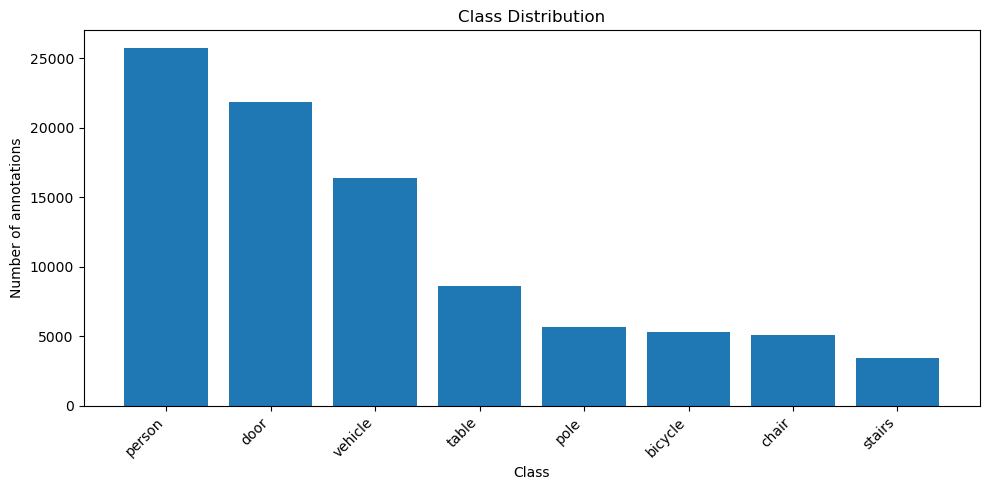

In [21]:
plt.figure(figsize=(10, 5))

plt.bar(
    class_balance["class_name"],
    class_balance["annotations"]
)

plt.xlabel("Class")
plt.ylabel("Number of annotations")
plt.title("Class Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [22]:
max_count = class_balance["annotations"].max()
min_count = class_balance["annotations"].min()

print(f"Most represented: {class_balance.iloc[0]['class_name']}")
print(f"Least represented: {class_balance.iloc[-1]['class_name']}")
print(f"Imbalance ratio: {max_count / min_count:.2f}:1")

Most represented: person
Least represented: stairs
Imbalance ratio: 7.53:1


In [25]:
image_records = []

for label_path in tqdm(
    PROCESSED_DIR.glob("*.txt"),
    desc="reading labels"
):
    image_path = label_path.with_suffix(".jpg")

    if not image_path.exists():
        image_path = label_path.with_suffix(".png")

    if not image_path.exists():
        continue

    classes = set()

    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) >= 5:
                try:
                    classes.add(int(parts[0]))
                except ValueError:
                    continue

    image_records.append({
        "image": image_path,
        "label": label_path,
        "classes": classes
    })

print(f"Valid image-label pairs: {len(image_records)}")

reading labels: 0it [00:00, ?it/s]

Valid image-label pairs: 35633


In [27]:
SEED = 42
random.seed(SEED)

TRAIN_RATIO = 0.70
VAL_RATIO = 0.20
TEST_RATIO = 0.10

records = image_records.copy()
random.shuffle(records)

target_counts = {
    "train": round(len(records) * TRAIN_RATIO),
    "val": round(len(records) * VAL_RATIO),
}

target_counts["test"] = (
    len(records)
    - target_counts["train"]
    - target_counts["val"]
)

splits = {
    "train": [],
    "val": [],
    "test": []
}

class_totals = Counter()

for record in records:
    for cls in record["classes"]:
        class_totals[cls] += 1

split_class_counts = {
    "train": Counter(),
    "val": Counter(),
    "test": Counter()
}

for record in records:
    best_split = None
    best_score = float("inf")

    for split in ["train", "val", "test"]:

        if len(splits[split]) >= target_counts[split]:
            continue

        score = 0

        for cls in record["classes"]:
            target = class_totals[cls] * {
                "train": TRAIN_RATIO,
                "val": VAL_RATIO,
                "test": TEST_RATIO
            }[split]

            current = split_class_counts[split][cls]

            score += max(0, current - target)

        score += len(splits[split]) / target_counts[split]

        if score < best_score:
            best_score = score
            best_split = split

    splits[best_split].append(record)

    for cls in record["classes"]:
        split_class_counts[best_split][cls] += 1

print("Split sizes:")

for split, records_split in splits.items():
    print(f"{split}: {len(records_split)}")

Split sizes:
train: 24943
val: 7127
test: 3563


In [30]:
for split in ["train", "val", "test"]:
    (DATASET_V2_DIR / "images" / split).mkdir(
        parents=True,
        exist_ok=True
    )
    (DATASET_V2_DIR / "labels" / split).mkdir(
        parents=True,
        exist_ok=True
    )

for split, records_split in splits.items():

    image_dir = DATASET_V2_DIR / "images" / split
    label_dir = DATASET_V2_DIR / "labels" / split

    for record in tqdm(
        records_split,
        desc=f"copying {split}"
    ):
        shutil.copy2(
            record["image"],
            image_dir / record["image"].name
        )

        shutil.copy2(
            record["label"],
            label_dir / record["label"].name
        )

print("Dataset split completed.")

copying train:   0%|          | 0/24943 [00:00<?, ?it/s]

copying val:   0%|          | 0/7127 [00:00<?, ?it/s]

copying test:   0%|          | 0/3563 [00:00<?, ?it/s]

Dataset split completed.


In [31]:
split_summary = []

for split in ["train", "val", "test"]:

    image_dir = DATASET_V2_DIR / "images" / split
    label_dir = DATASET_V2_DIR / "labels" / split

    images = [
        p for p in image_dir.iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ]

    labels = list(label_dir.glob("*.txt"))

    image_stems = {p.stem for p in images}
    label_stems = {p.stem for p in labels}

    split_summary.append({
        "split": split,
        "images": len(images),
        "labels": len(labels),
        "missing_labels": len(image_stems - label_stems),
        "orphan_labels": len(label_stems - image_stems)
    })

display(pd.DataFrame(split_summary))

,split,images,labels,missing_labels,orphan_labels
0,train,24943,24943,0,0
1,val,7127,7127,0,0
2,test,3563,3563,0,0


In [35]:
DATA_YAML = CONFIG_DIR / "data.yaml"

data_yaml = {
    "path": str(DATASET_V2_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": len(CLASS_ID_TO_NAME),
    "names": [CLASS_ID_TO_NAME[i] for i in sorted(CLASS_ID_TO_NAME)]
}

with open(DATA_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print(f"Created: {DATA_YAML}")
print("\nContents:")
print(yaml.safe_dump(data_yaml, sort_keys=False))

Created: D:\SIT374\WalkBuddy-T2-2026\ML_side\config\data.yaml

Contents:
path: D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\dataset_v2
train: images/train
val: images/val
test: images/test
nc: 8
names:
- person
- stairs
- door
- chair
- table
- pole
- bicycle
- vehicle



---

End of report (for now)

---